# Assignment2 - Supervised Machine Learning Fundamentals

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


---
## Exercise 1 - Conceptual Questions on Supervised Learning I

**1.1**     
Expect better.          
Because large n can fit the underlying pattern more accuratly without as much risk of overfitting. Also, large n provides enough information to distinguish the singal from the noise, allowing a flexible model to find a closer fit to teh true functional form.

**1.2**     
Expect worse.       
Few data means the flexible model will find the pattern in the random noise, which is overfitting. Inflexible model perform better because their contrains prevent them from chasing every outlier in a small sample.

**1.3**     
Expect better.          
The flexible method makes strong assumptions about the shape of the data. If the true relationship is curvy or complex, and inflexible model will have high bias.

**1.4**     
Expect worse.           
High variance means the data has high noise. A flexible method will follow the noise, mistaking random fluctuations for the actual relationship. Inflexible method is more robust because it effectively averages out the noise to be more simpler.


---
## Exercise 2 - Conceptual Questions on Supervised learning II

**2.1**     
(i) Regression, because the response variable is the salary and salary is the continuous value.     
(ii) Inference, becuae the question wants us to understand which factors affect CEO salary, which means we need to know the relationship between different variable, not just predict the new data.         
(iii) Sample n = 500, predictor p = 3(profit, number of employees, industry)        

**2.2**         
(i) Classification, because the response variable is whether the product is a success or failure, which is discrete             
(ii) Prediction, because the goal is to determine the likely outcome a future product based on existing data.           
(iii) Sample n = 20, predictor p = 13

**2.3**

(i) Regression, because the response variable is % change in the US dollar, which is a continuous numerical value.          
(ii) Prediction, because we're interested in using world market changes to estimate the future movement of dollar.          
(iii) Sample n = 52 (52 weeks per year), predictor p = 3 (% change in US, British, German)

---
## Exercise 3 - Classification using KNN

**3.1**

In [2]:
import numpy as np
import pandas as pd
X = np.array([[ 0, 3, 0],
              [ 2, 0, 0],
              [ 0, 1, 3],
              [ 0, 1, 2],
              [-1, 0, 1],
              [ 1, 1, 1]])
y = np.array(['r','r','r','b','b','r'])

test_point = np.array([0, 0, 0])
distance = np.linalg.norm(X - test_point, axis = 1)
df = pd.DataFrame({'Obs.': np.arange(1, 7),'x1': X[:, 0],'x2': X[:, 1],'x3': X[:, 2],'y': y,'Distance': distance})

print(df.to_string(index = False))

 Obs.  x1  x2  x3 y  Distance
    1   0   3   0 r  3.000000
    2   2   0   0 r  2.000000
    3   0   1   3 r  3.162278
    4   0   1   2 b  2.236068
    5  -1   0   1 b  1.414214
    6   1   1   1 r  1.732051


**3.2**             
Predict when k = 1          
Ans: Blue, when k = 1, the prediction is based on the single observation in the training set that is closest to the test point, which is obs 5 (blue).

**3.3**         
Predict when k = 3      
Ans: Red        
Base on the Euclidean distance, the three observations closest to the test point are obs5, obs6, obs2.      
2 red labels and 1 blue label, so KNN predicts y = red.

**3.4**         
I would expect the best value of k to be small.         
A small k provides a more flexible model with a lower bias, allowing the decision boundary to follow non-linear patterns in the data.       
Also if K increases, the decision boundary becomes more linear because it averages the labels over a larger neighborhood.
Therefore, a highly non-linear Bayes ecision boundary requires the model to capture complex shapes, a small K is necessary to provide the required.

---
## Exercise 4 - Build my own classification algorithm

**4.1**

In [3]:
# Skeleton code for part (a) to write your own kNN classifier

class Knn:
# k-Nearest Neighbor class object for classification training and testing
    def __init__(self):
        self.x_train = None
        self.y_train = None
    def fit(self, x, y):
        # Save the training data to properties of this class
        self.x_train = x 
        self.y_train = y
        
    def predict(self, x, k):
        y_hat = [] # Variable to store the estimated class label for 
        # Calculate the distance from each vector in x to the training data
        for test in x:
            distance = np.sqrt(np.sum((self.x_train - test) ** 2, axis = 1))
            nearest_neighbor = np.argsort(distance)[:k]
            k_nearest_labels = self.y_train[nearest_neighbor]
            unique, counts = np.unique(k_nearest_labels, return_counts=True)
            prediction = unique[np.argmax(counts)]
            y_hat.append(prediction)
        # Return the estimated targets
        return np.array(y_hat)

# Metric of overall classification accuracy
#  (a more general function, sklearn.metrics.accuracy_score, is also available)
def accuracy(y,y_hat):
    nvalues = len(y)
    accuracy = sum(y == y_hat) / nvalues
    return accuracy

**4.2 Load the datasets**

In [4]:
import pandas as pd

x_train_low = pd.read_csv('data/A2_Q4_X_train_low.csv' , header=None).values
y_train_low = pd.read_csv('data/A2_Q4_y_train_low.csv' , header=None).values.flatten()
x_test_low  = pd.read_csv('data/A2_Q4_X_test_low.csv', header=None).values
y_test_low  = pd.read_csv('data/A2_Q4_y_test_low.csv', header=None).values.flatten()
x_train_high = pd.read_csv('data/A2_Q4_X_train_high.csv', header=None).values
y_train_high = pd.read_csv('data/A2_Q4_y_train_high.csv', header=None).values.flatten()
x_test_high  = pd.read_csv('data/A2_Q4_X_test_high.csv', header=None).values
y_test_high  = pd.read_csv('data/A2_Q4_y_test_high.csv', header=None).values.flatten()
print(f"Low-dim train shape: {x_train_low.shape}")   
print(f"High-dim train shape: {x_train_high.shape}") 

Low-dim train shape: (1000, 2)
High-dim train shape: (1000, 100)


**4.3 Model Result**

In [5]:
import time
def evaluate(x_train, y_train, x_test, y_test, k=5, label="Dataset"):
    knn = Knn()
    knn.fit(x_train, y_train)
    start_time = time.time()
    y_hat = knn.predict(x_test, k=k)
    end_time = time.time()
    acc = accuracy(y_test, y_hat)
    duration = end_time - start_time
    
    print(f"--- {label} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Time taken: {duration:.4f} seconds\n")
    return acc, duration

acc_low, time_low = evaluate(x_train_low, y_train_low, x_test_low, y_test_low, k=5, label="Low Dimensional (p=2)")
acc_high, time_high = evaluate(x_train_high, y_train_high, x_test_high, y_test_high, k=5, label="High Dimensional (p=100)")

--- Low Dimensional (p=2) ---
Accuracy: 0.9250
Time taken: 0.1215 seconds

--- High Dimensional (p=100) ---
Accuracy: 0.9930
Time taken: 0.5500 seconds



**4.4 Compare with sklearn result**

In [8]:
from sklearn.neighbors import KNeighborsClassifier
sk_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', algorithm='brute')
sk_knn.fit(x_train_low, y_train_low)
start = time.time()
sk_y_hat = sk_knn.predict(x_test_low)
sk_time = time.time() - start
print("--- Low Dimensional ---")
print(f"Sklearn Accuracy: {accuracy(y_test_low, sk_y_hat):.4f}")
print(f"Sklearn Time: {sk_time:.4f}s")

sk_knn.fit(x_train_high, y_train_high)
start = time.time()
sk_y_hat = sk_knn.predict(x_test_high)
sk_time = time.time() - start
print("\n--- High Dimensional ---")
print(f"Sklearn Accuracy: {accuracy(y_test_high, sk_y_hat):.4f}")
print(f"Sklearn Time: {sk_time:.4f}s")

--- Low Dimensional ---
Sklearn Accuracy: 0.9250
Sklearn Time: 0.0390s

--- High Dimensional ---
Sklearn Accuracy: 0.9930
Sklearn Time: 0.0380s


The SKlearn accuracy for the low and high dimensional is exactly the same as my own model's result.     
But the performance has gap, the sklearn time is much faster than mine.

**4.5**   
**Drawback:**       
      
If the prediction process is slow, the model cannot provide immediate feedback, which is critical for the systems that requiring real-time interaction. Also it requires more CPU/GPU resources for every single new data point. Additionally, if we need to process millions of predictions, slow inference can create a massive lag that stalls the entire system.        

**Some Cases:**          
1. Like high frequency trading, in the stock market, algorithms make trades in microseconds. If the inference process is slower than competitior's, the opportunity for the profit may lost.       
2. Self-driving car must classify many situation in microseconds. While trainging the model can take a lot of time on supercomputer, a slow inference speed in this field could lead to accidents.
   



---
## Exercise 5 - Bias-variance tradeoff: exploring the tradeoff with a KNN classifer


**5.1 Create a synthetic data** 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from matplotlib.colors import LinearSegmentedColormap

X, y = make_moons(n_samples=1000, noise=0.35, random_state=42)
colors = [(255/255, 150/255, 150/255), (150/255, 180/255, 255/255)]
newcmp = LinearSegmentedColormap.from_list("new", colors, N=2)

**5.2 Visiualize data**

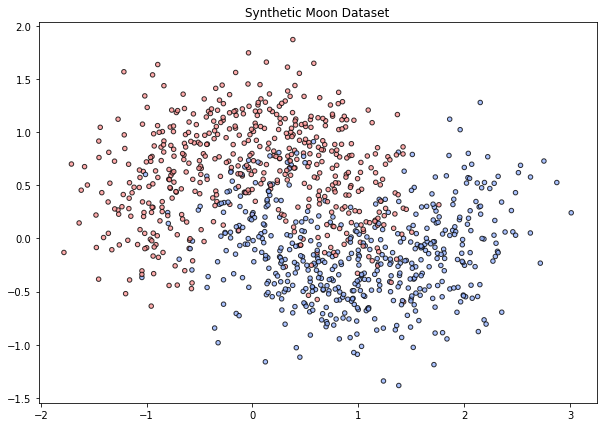

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=newcmp, edgecolor='k', s=20, alpha=0.8)
plt.title("Synthetic Moon Dataset")
plt.show()

**5.3**

In [15]:
models = []
dataset = []

np.random.seed(42)

# Repeat 3 times to generate 3 different dataset
for i in range(3):
    indices = np.random.choice(range(len(x)), size = 100, replace=True)
    x_subset = X[indices]
    y_subset = y[indices]
    dataset.append((x_subset, y_subset))

    subset_models = {}
    for k in [1, 25, 50]:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(x_subset, y_subset)
        subset_models[k] = knn

    models.append(subset_models)
print(f"Successfully trained {len(models) * 3} combinations")

Successfully trained 9 combinations
